# MITGCM Regional Spatial Scale Analysis 

**Purpose**: Code for preforming the regional spatial decorrelation scale analysis. Here, we compute the decorrelation spatial scale for a subset of the model domain within a regions (~20 km radius) around the CCE Moorings. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Ignore warnings

In [2]:
import warnings
warnings.filterwarnings("ignore")

Import python libraries

In [20]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
from pyproj import Geod
from scipy.ndimage import map_coordinates
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize
from lsf import unweighted_lsf, detrend
from ocean_analysis import rotate_field, interpolate_to_polar_grid
from stats import compute_variance_ellipse
from plotScaleAnalysis import month_fmt

Set plotting parameters

In [4]:
fontsize = 16

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Set data analysis parameters

In [5]:
# Set processing parameters
option_plot          = 0          # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, uvel, vvel, 'curl', 'div', 'strain', 'speed', 'dir'
option_depth         = 9          # Specifies the depth level in meter at which the decorrelation data is computed
option_sample        = 0          # Specifies what sampling strategies is used for the model. If True, the model is sampled at CCE1 and CCE2. 

# Set time and space parameters
T            = 1*(60)*(60)                   # Spcifies the time interval for model run. Units: seconds
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze
if option_sample == True:
    moorings = {                                  
        "CCE1": (33.457, 237.47767),  
        "CCE2": (34.3075, 239.19580000000002),
        "CCE3": (34.44825228022894, 239.46174298472215),
        "CCE4": (33.9, 238.4)
    }                      # Mooring poitions
    half_widths = {
        "CCE1": 23, 
        "CCE2": 23,  
        "CCE3": 6, 
        "CCE4": 23   
    }                       # half-widths (Units: km)
else:                                         
    moorings = {                                  
        "mooring1": (33.75, 238.0),
        "mooring2": (34.25, 238.9)   # (34.15, 238.7)
    }                                            # Mooring poitions
    half_widths = {
        "mooring1": 50,
        "mooring2": 50   
    }                                            # half-widths (Units: km)

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

Load mitgcm data netcdf files 

In [6]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_map_depth_" + str(option_depth) + "m.nc"
elif (option_var == 'uvel') | (option_var == 'vvel'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_map_depth_" + str(option_depth) + "m.nc"
elif (option_var == 'curl') | (option_var == 'div') | (option_var == 'strain') | (option_var == 'speed'):
    filename = PATH + "mitgcm_intermediate_data_vel_gradients_hrly_map_depth_" + str(option_depth) + "m.nc"
nc = Dataset(filename, 'r')

# Extract data variables
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density') | (option_var == 'uvel') | (option_var == 'vvel'): 
    depth = nc.variables['Depth'][:]
    lon = nc.variables['lon'][:]
    lat = nc.variables['lat'][:]
    time =  num2date(nc.variables['time'][:], nc.variables['time'].units)
else: 
    lon = nc.variables['lon'][:]
    lat = nc.variables['lat'][:]
    time =  num2date(nc.variables['time_dt'][:], nc.variables['time_dt'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'uvel':
    data = nc.variables['u'][:]
elif option_var == 'vvel':
    data = nc.variables['v'][:]
elif option_var == 'curl':
    data = nc.variables['CURL'][:]
elif option_var == 'div':
    data = nc.variables['DIV'][:]
elif option_var == 'strain':
    data = nc.variables['STRAIN'][:]
elif option_var == 'speed': 
    data = nc.variables['SPEED'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Read in bathymetry data

In [7]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Extract regional domains around the CCE moorings 

In [8]:
# Set data extraction parameters
geod = Geod(ellps="WGS84")  # Geodesic

# Set least-square fit parameters
ntime,nlat,nlon = np.shape(data)
w1, w2 = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/hr

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Convert longitudes to match MITgcm convention if necessary
if np.any(lon > 180):
    moorings = {k: (v[0], (v[1] + 360) if v[1] < 0 else v[1]) for k, v in moorings.items()}

# Initialize arrays
region_data = {}

# Loop through mooring locations
for name, (lat_moor, lon_moor) in moorings.items():

    # Set half width
    half_width_km = half_widths[name]

    # Find closest gridpoint to mooring
    i_lat = np.argmin(np.abs(lat - lat_moor))
    i_lon = np.argmin(np.abs(lon - lon_moor))

    # Creat an array of longitude/latitude values the length of the latitude/longitude vector
    lon_col = np.full(len(lat) - 1, lon[i_lon]) 
    lat_col = np.full(len(lon) - 1, lat[i_lat])

    #--- Compute distances along lat and lon directions ---# 

    # Distance (km) between adjacent lat points at the mooring longitude
    _, _, dy_m = geod.inv(
        lon_col, lat[:-1],
        lon_col, lat[1:]
    )
    dy = np.abs(dy_m / 1000.0)  # convert to km

    # Distance (km) between adjacent lon points at the mooring latitude
    _, _, dx = geod.inv(
        lon[:-1], lat_col,
        lon[1:], lat_col
    )
    dx = np.abs(dx / 1000.0)  # convert to km

    #--- Compute cumulative distances from center grid point ---# 

    # Initialize cumulative distance arrays
    lat_dist_km = np.empty(len(lat), dtype=float)
    lat_dist_km[i_lat] = 0.0
    lon_dist_km = np.empty(len(lon), dtype=float)
    lon_dist_km[i_lon] = 0.0

    # Compute distances (km) from the mooring grid cell to every latitude index 
    lat_dist_km[:i_lat] = np.cumsum(dy[:i_lat][::-1])[::-1]  # South of center (indices < i_lat): cumulative sum of dy going up toward i_lat
    lat_dist_km[i_lat+1:] = np.cumsum(dy[i_lat:])            # North of center (indices > i_lat): cumulative sum forward from i_lat

    # Compute distances (km) from the mooring grid cell to every longitude index
    lon_dist_km[:i_lon] = np.cumsum(dx[:i_lon][::-1])[::-1] # West of center (indices < i_lon): cumulative sum of dy going left toward i_lon
    lon_dist_km[i_lon+1:] = np.cumsum(dx[i_lon:])           # East of center (indices > i_lon): cumulative sum forward from i_lon

    # Identify indices within + or - half_width_km
    lat_mask = lat_dist_km <= half_width_km
    lon_mask = lon_dist_km <= half_width_km

    # Extract the data
    region  = data[:, lat_mask, :][:, :, lon_mask]
    lat_reg = lat[lat_mask]
    lon_reg = lon[lon_mask]

    # Initialize array
    nlon = len(lon_reg)
    nlat = len(lat_reg)
    region_r = np.zeros((ntime,nlat,nlon)) 

    # Loop through longitude
    for ilon in range(0,nlon): 

        # Loop through latitude
        for ilat in range(0,nlat): 

            # Initialize the ith time series 
            region_ts = region[:,ilat,ilon]

            # Attempt removing the annual and semi-annual cycles
            try:

                # Remove time mean and annual and semi-annual cycles 
                hfit, x_data, x_data_sigma, _ = unweighted_lsf(region_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                region_r[:,ilat,ilon] = region_ts - hfit

            except Exception as e:

                print(f"Something went wrong: {e}")

    region_data[name] = {
        "data": region_r,
        "lat_subset": lat[lat_mask],
        "lon_subset": lon[lon_mask]
    }

# --- Check resulting shapes ---
for k, v in region_data.items():
    print(f"{k}: {v['data'].shape}")

Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.
Something went wrong: No valid (unmasked) data points available for fitting.

Pick a single time step to evalute the decorrelation ellipse

In [9]:
# Set targets for seasonal snapshots
winter_target = datetime(2016, 1, 12) #datetime(2016, 12, 29)
summer_target = datetime(2017, 7, 1)
spring_target = datetime(2017, 5, 17)

# Find indices
idx_winter = np.where(time_dt == winter_target)[0][0]
idx_summer = np.where(time_dt == summer_target)[0][0]
idx_spring = np.where(time_dt == spring_target)[0][0]

# Extract instantaneous time slices for full study domain 
data_winter = np.squeeze(data[idx_winter, ...])
data_summer = np.squeeze(data[idx_summer, ...])
data_spring = np.squeeze(data[idx_spring, ...])

time_winter = time_dt[idx_winter]
time_spring = time_dt[idx_spring]
time_summer = time_dt[idx_summer]

Plot one data field snapshot and each spatial region

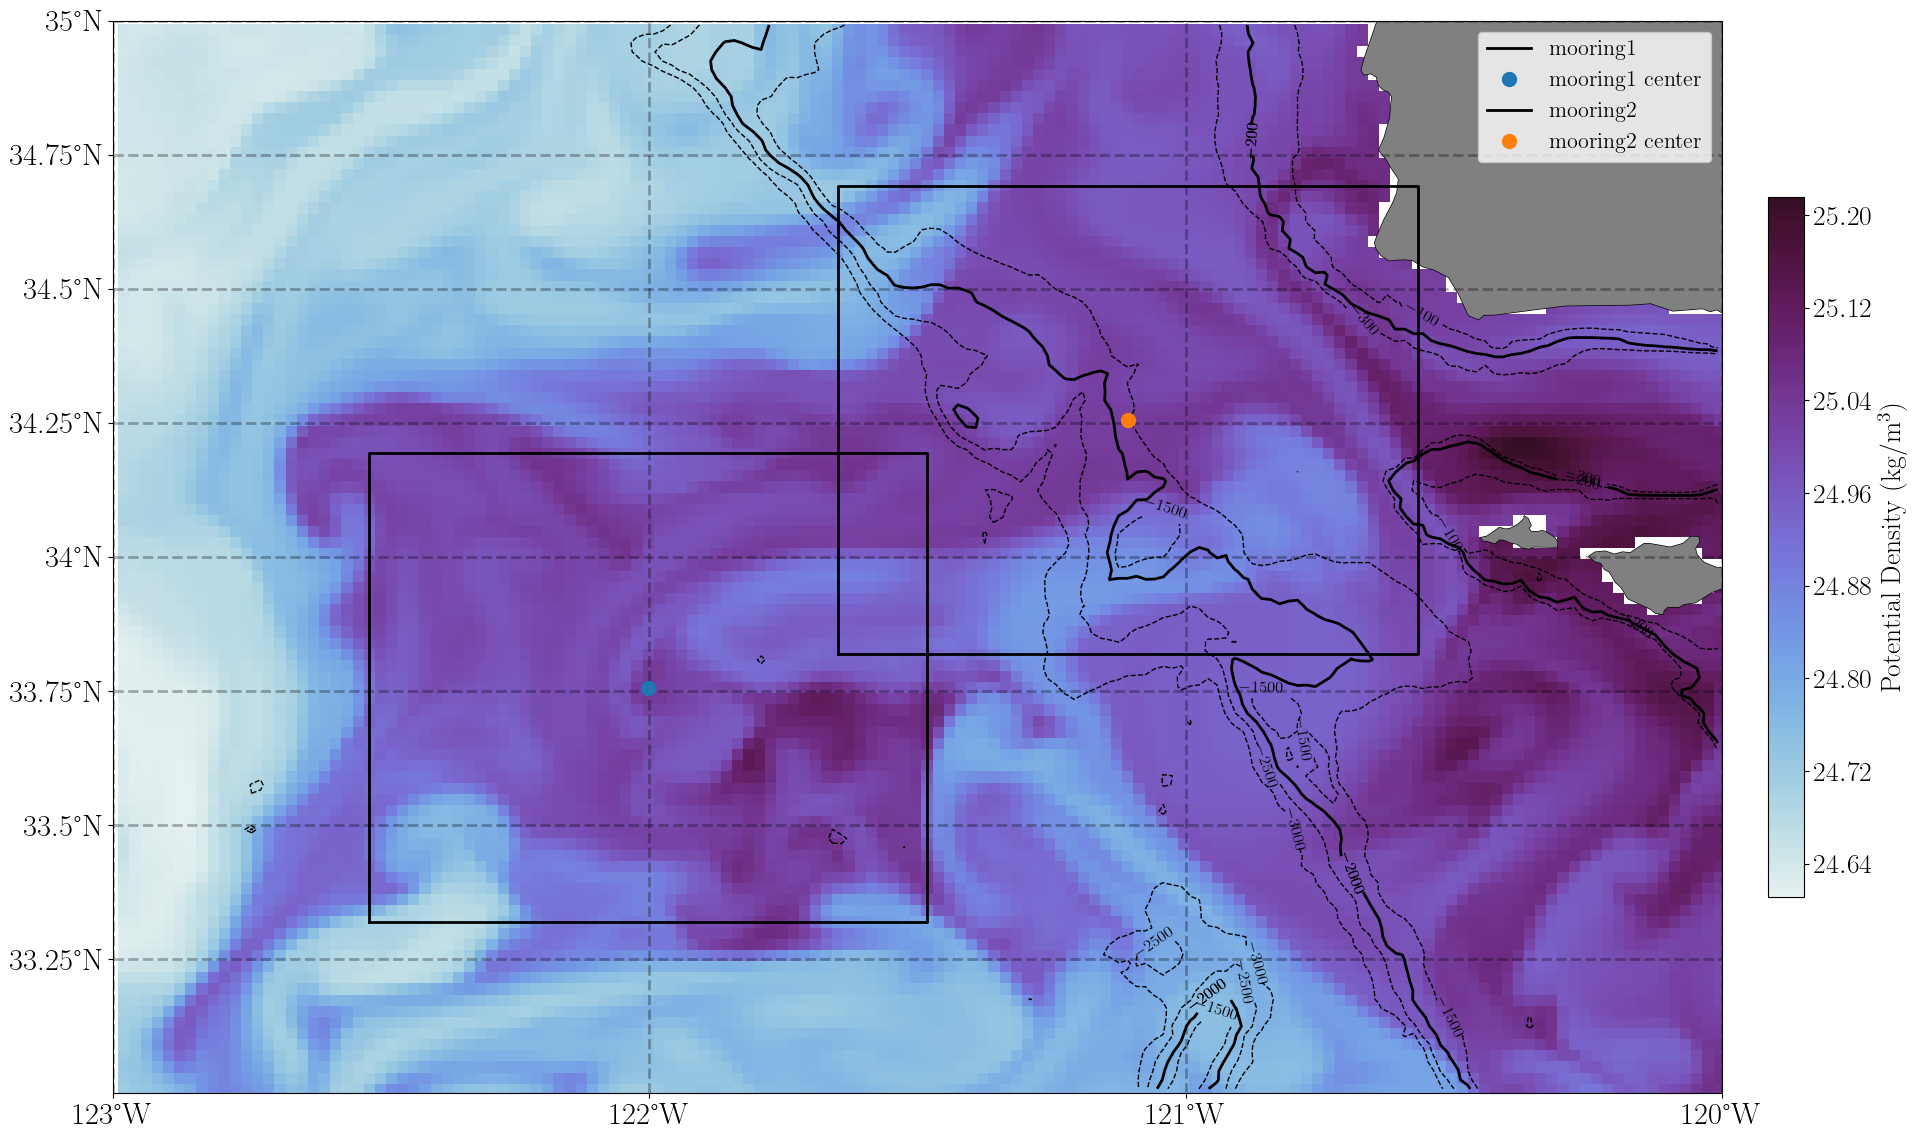

In [19]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35

# Specify data specific attributes 
if option_var == 'temp':
    cmap = cmo.thermal
    label = r'Conservative Temperature ($^\circ$C)'
    levels = np.arange(13,15.25+0.1,0.1) 
elif option_var == 'sal':
    cmap = cmo.haline
    label = r'Absolute Salinity (g/kg)'
    levels = np.arange(32.85,33.75 + 0.02,0.02)
elif option_var == 'density': 
    cmap = cmo.dense
    label = r'Potential Density (kg/m$^{3}$)'
    levels = np.arange(24.6,25.2 + 0.015,0.015)
elif option_var == 'curl': 
    cmap = cmo.balance
    label = r'Ro $= \zeta/f$'
    levels = np.arange(-1,1+0.05,0.05)

# Create base figure
fig, ax = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot full field as background
cf = ax.pcolormesh(lon, lat, data_winter, cmap=cmap, transform=ccrs.PlateCarree())

# Plot depth contour lines
level_innershelf = np.arange(-300,0,100)
levels_midshelf = np.arange(-3000,-1000,500)
contour1 = ax.contour(lon_grid, lat_grid, bathy_grid,levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, bathy_grid,levels=[-2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, bathy_grid,levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, bathy_grid,levels=[-200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set constants for local metric conversions
R_km = 6371.0
deg2rad = np.pi / 180.0
rad2deg = 180.0 / np.pi

# # Overlay extracted regions
# for name, region in region_data.items():
#     lat_box = region['lat_subset']
#     lon_box = region['lon_subset']

#     # Rectangle bounds
#     lon0 = 0.5 * (lon_box.min() + lon_box.max())
#     lat0 = 0.5 * (lat_box.min() + lat_box.max())
#     dlon = 0.5 * (lon_box.max() - lon_box.min())  # degrees
#     dlat = 0.5 * (lat_box.max() - lat_box.min())  # degrees

#     # Convert half-widths to km in a local ENU approximation
#     phi0 = lat0 * deg2rad
#     halfwidth_x_km = R_km * np.cos(phi0) * (dlon * deg2rad)  # E-W half-width
#     halfwidth_y_km = R_km * (dlat * deg2rad)                 # N-S half-width

#     # Largest inscribed circle radius (km)
#     r_km = np.minimum(halfwidth_x_km, halfwidth_y_km)

#     # Parametric circle in local (x, y) km, then map back to lon/lat
#     t = np.linspace(0, 2*np.pi, 361)
#     x_km = r_km * np.cos(t)  # east
#     y_km = r_km * np.sin(t)  # north

#     # Inverse local mapping to lon/lat (degrees)
#     lon_circle = lon0 + (x_km / (R_km * np.cos(phi0))) * rad2deg
#     lat_circle = lat0 + (y_km / R_km) * rad2deg

#     # Plot the circle outline
#     ax.plot(lon_circle, lat_circle, color='black', linewidth=2,
#             label=f"{name} circle", transform=ccrs.PlateCarree())

#     # Plot center point
#     ax.plot(lon0, lat0, 'o', markersize=10, label=f"{name} center",
#             transform=ccrs.PlateCarree())

# Overlay extracted regions
for name, region in region_data.items():
    lat_box = region['lat_subset']
    lon_box = region['lon_subset']
    lat_center = np.mean(lat_box)
    lon_center = np.mean(lon_box)
    
    # Plot box outline
    ax.plot(
        [lon_box.min(), lon_box.max(), lon_box.max(), lon_box.min(), lon_box.min()],
        [lat_box.min(), lat_box.min(), lat_box.max(), lat_box.max(), lat_box.min()],
        color='black', linewidth=2, label=name, transform=ccrs.PlateCarree()
    )
    
    # Plot center point
    ax.plot(lon_center, lat_center, 'o', markersize=10, label=f"{name} center", transform=ccrs.PlateCarree())

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.99, 0.33, 0.02, 0.35])
cart.set_cbar(
    cf,
    cax,
    fig,
    orientation="vertical",
    extend="neither",
    cbar_label=label,
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Set Legend
ax.legend()

# Display figure
plt.tight_layout()
plt.show()

## **Section 1**: Compute decorrelation scales for snapshots from each season

Now, let's compute the decorrelation scale ellipse at each mooring site

In [16]:
# Set parameters
seasons = ['winter', 'spring', 'summer']  

# Initialize arrays and counters
cn_m = 0
nmooring, nseason = len(region_data.keys()), len(seasons)
theta_dict = {}
L_theta = {}

# Loop through moorings 
for name, region in region_data.items():

    # Set a key in the dictionary
    theta_dict[name] = {}
    L_theta[name] = {}

    # Print the Name of the mooring 
    print(name)

    # Extract data 
    idata = region["data"]
    ilon  = region["lon_subset"]
    ilat  = region["lat_subset"]

    # Initialize counter
    cn_s = 0

    # Loop through seasons
    for iseason in seasons:

        # Grab data snap shot from a season 
        if iseason == 'winter': 
            idata_s = np.squeeze(idata[idx_winter,:,:])
        elif iseason == 'spring':
            idata_s = np.squeeze(idata[idx_spring,:,:]) 
        elif iseason == 'summer': 
            idata_s = np.squeeze(idata[idx_summer,:,:])

        # Interpolate to polar grid (cropped to inscribed circle)
        lon_center, lat_center = np.mean(ilon), np.mean(ilat)
        LON, LAT = np.meshgrid(ilon, ilat)
        R, THETA, data_polar, _ = interpolate_to_polar_grid(LON, LAT, idata_s, lon_center, lat_center)

        # Convert r and theta output into vectors
        r = R[0,:]
        theta = THETA[:,0]*(180/np.pi)

        # Set number of elements
        nr = len(r)
        ntheta = len(theta)
        dr = r[1] - r[0]

         # Mask invalid (NaN or Inf) points 
        data_m = np.ma.masked_invalid(data_polar)

        # Initialize array 
        iL_theta = np.zeros((ntheta,1))

        # Loop through rotation angles 
        for iangle in range(0,ntheta): 

            # Detrend data record 
            data_dt = detrend(data_m[iangle,:], r, mean = 0)
            
            # Compute autocorrelation function at the ith angle 
            autocorr, _, _, _, space_lag, _ = compute_autocorr_optimize(data_dt, r, nr, 'biased', 0)

            # Compute the decorrelation scale 
            iL_theta[iangle] = compute_decor_scale_optimize(autocorr, space_lag, dr, 'unbiased', 0)

        # Save data into dictionary 
        theta_dict[name][iseason] = theta
        L_theta[name][iseason] = np.array(iL_theta)

        # Reset season counter 
        cn_s += 1

    # Reset mooring counter 
    cn_m += 1

mooring1
mooring2


Plot the decorrelation scale ellipse for each season

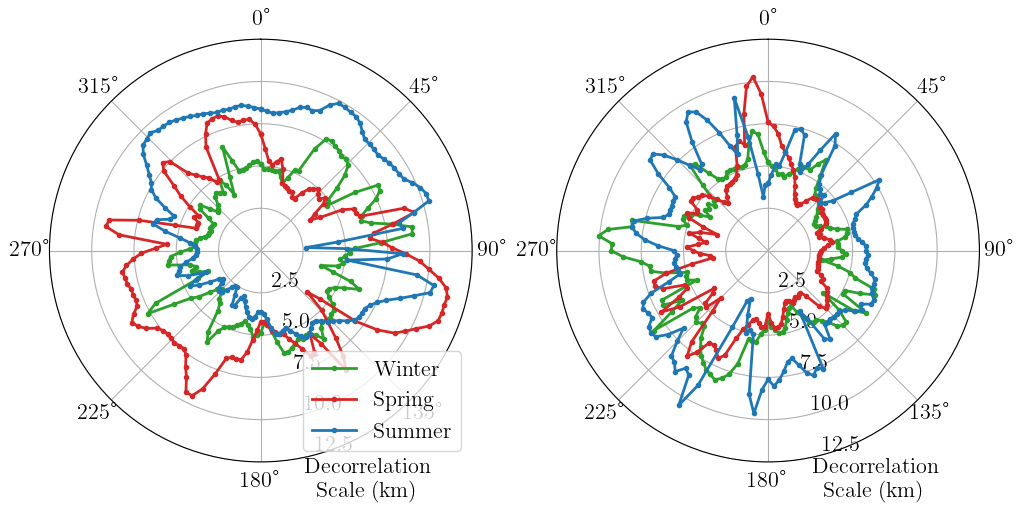

In [17]:
# Set plotting parameter 
r_grid = [2.5, 5, 7.5, 10, 12.5]

# Create figure and axes 
fig, axes = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection': 'polar'})
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
theta_rad_winter_m1 = np.deg2rad(theta_dict['mooring1']['winter'])
theta_rad_spring_m1 = np.deg2rad(theta_dict['mooring1']['spring'])
theta_rad_summer_m1 = np.deg2rad(theta_dict['mooring1']['summer'])

# Plot the decorrelation ellipse
ax1.plot(theta_rad_winter_m1,L_theta['mooring1']['winter'],'.-', color='tab:green', linewidth=2, label='Winter')
ax1.plot(theta_rad_spring_m1,L_theta['mooring1']['spring'],'.-', color='tab:red', linewidth=2, label='Spring')
ax1.plot(theta_rad_summer_m1,L_theta['mooring1']['summer'],'.-', color='tab:blue', linewidth=2, label='Summer')

# Set figure attributes 
ax1.set_theta_zero_location('N')   
ax1.set_theta_direction(-1)        
ax1.set_rmax(12.5)
ax1.set_rgrids(r_grid, angle=165)
ax1.text(np.deg2rad(155), 15, f"Decorrelation\nScale (km)", ha='center', va='center')
ax1.grid(True)
ax1.legend()

#--- Subplot 2 ---# 
theta_rad_winter_m2 = np.deg2rad(theta_dict['mooring2']['winter'])
theta_rad_spring_m2 = np.deg2rad(theta_dict['mooring2']['spring'])
theta_rad_summer_m2 = np.deg2rad(theta_dict['mooring2']['summer'])

# Plot the decorrelation ellipse
ax2.plot(theta_rad_winter_m2,L_theta['mooring2']['winter'],'.-', color='tab:green', linewidth=2, label='Winter')
ax2.plot(theta_rad_spring_m2,L_theta['mooring2']['spring'],'.-', color='tab:red', linewidth=2, label='Spring')
ax2.plot(theta_rad_summer_m2,L_theta['mooring2']['summer'],'.-', color='tab:blue', linewidth=2, label='Summer')

# Set figure attributes 
ax2.set_theta_zero_location('N')   
ax2.set_theta_direction(-1)        
ax2.set_rmax(12.5)
ax2.set_rgrids(r_grid, angle=165)
ax2.text(np.deg2rad(155), 15, f"Decorrelation\nScale (km)", ha='center', va='center')
ax2.grid(True)

Plot the density feilds for each seasons 

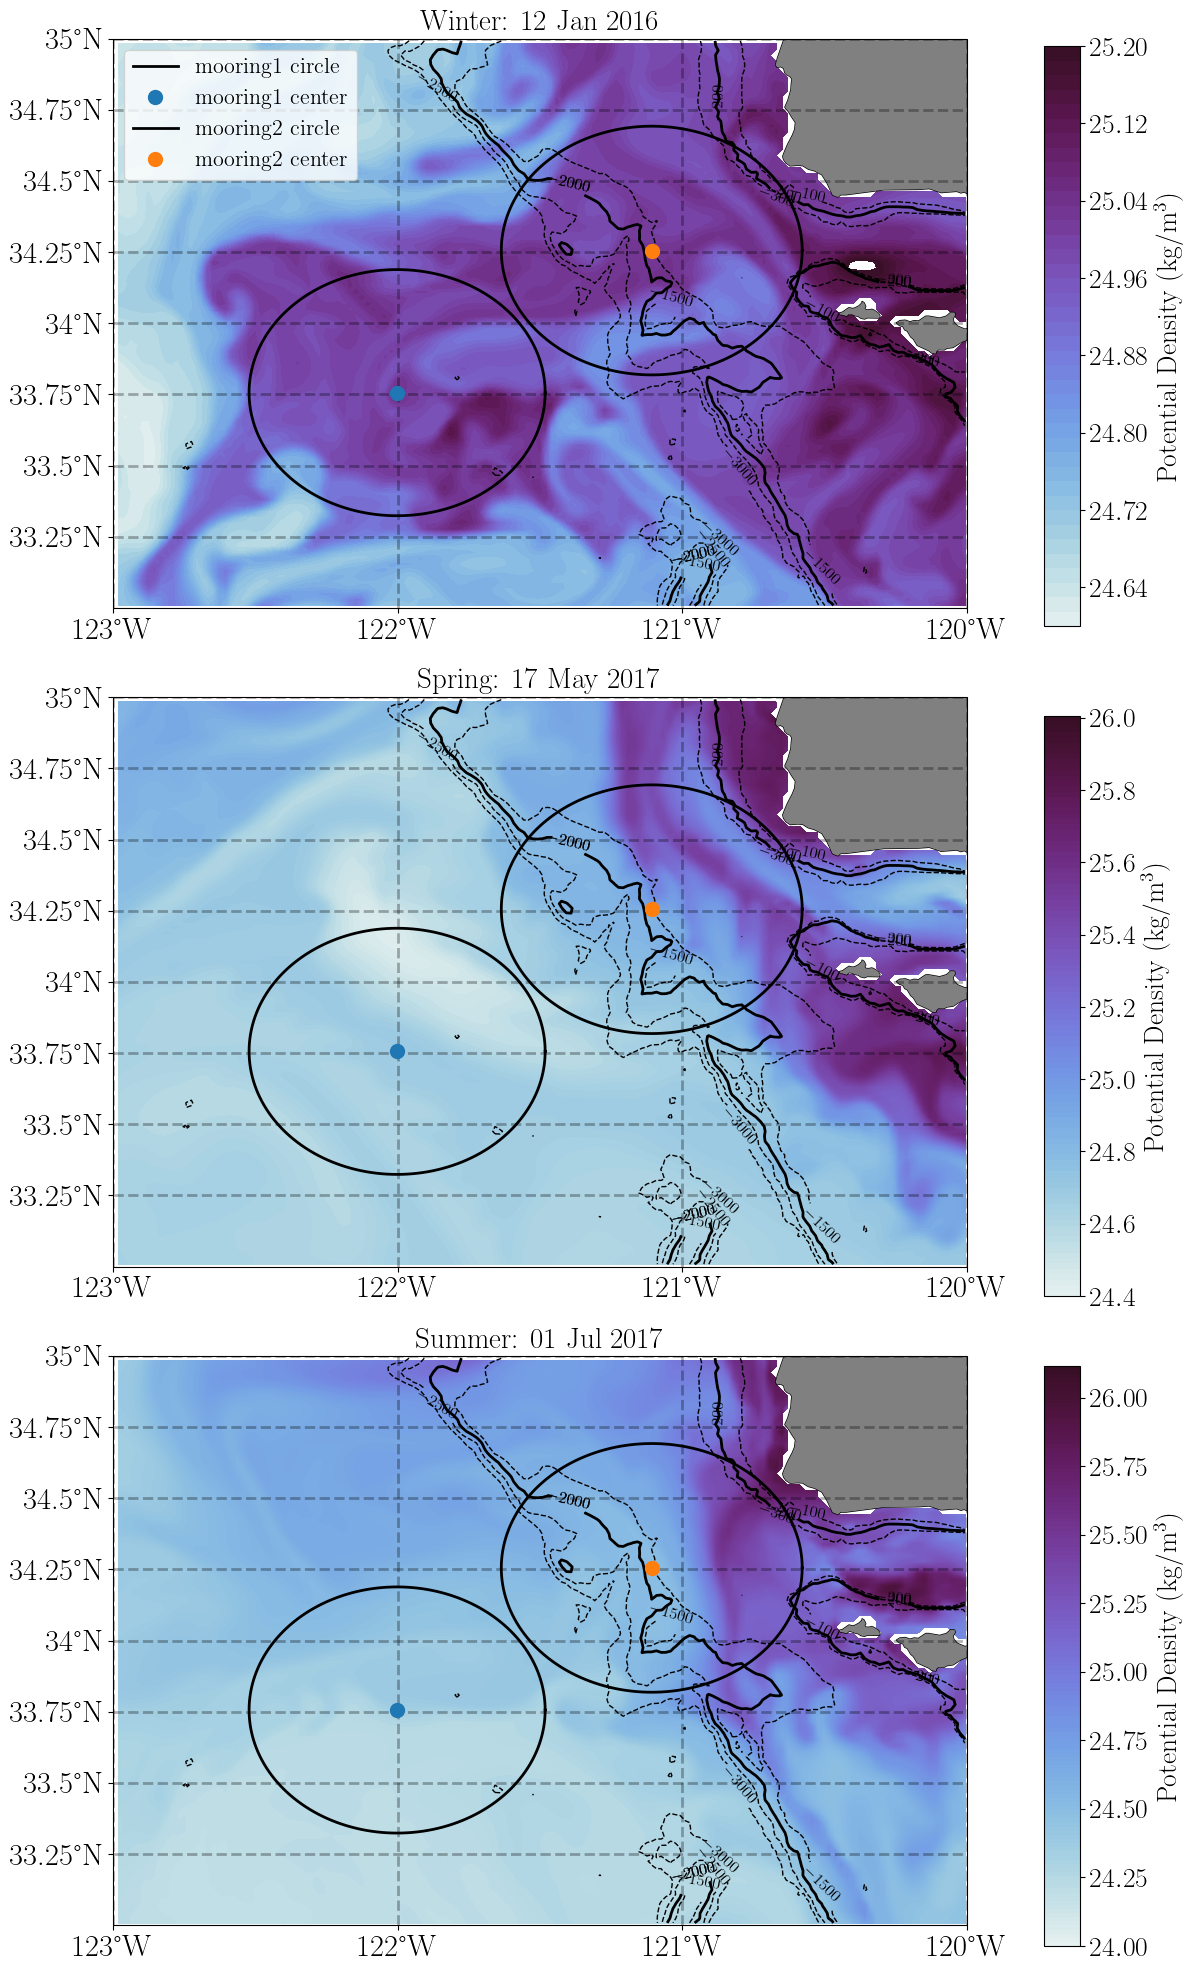

In [13]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35
levels_winter = np.arange(24.6,25.2 + 0.015,0.015)
levels_spring = np.arange(24.4,26.0 + 0.015,0.015)
levels_summer = np.arange(24.0,26.1 + 0.015,0.015)

# Create base figure
fig, axes = plt.subplots(3,1, figsize=(18, 20), subplot_kw={"projection": projection})
ax1, ax2, ax3 = axes.flatten()

###################
#--- Subplot 1 ---#
################### 

# Set figure axes 
cart.set_subplots(ax1, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot full field as background
cf = ax1.contourf(lon, lat, data_winter, levels=levels_winter, cmap=cmap, transform=ccrs.PlateCarree(), extend='neither')

# Plot depth contour lines
level_innershelf = np.arange(-300,0,100)
levels_midshelf = np.arange(-3000,-1000,500)
contour1 = ax1.contour(lon_grid, lat_grid, bathy_grid,levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax1.contour(lon_grid, lat_grid, bathy_grid,levels=[-2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax1.contour(lon_grid, lat_grid, bathy_grid,levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax1.contour(lon_grid, lat_grid, bathy_grid,levels=[-200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Overlay extracted regions
for name, region in region_data.items():
    lat_box = region['lat_subset']
    lon_box = region['lon_subset']

    # Rectangle bounds
    lon0 = 0.5 * (lon_box.min() + lon_box.max())
    lat0 = 0.5 * (lat_box.min() + lat_box.max())
    dlon = 0.5 * (lon_box.max() - lon_box.min())  # degrees
    dlat = 0.5 * (lat_box.max() - lat_box.min())  # degrees

    # Convert half-widths to km in a local ENU approximation
    phi0 = lat0 * deg2rad
    halfwidth_x_km = R_km * np.cos(phi0) * (dlon * deg2rad)  # E-W half-width
    halfwidth_y_km = R_km * (dlat * deg2rad)                 # N-S half-width

    # Largest inscribed circle radius (km)
    r_km = np.minimum(halfwidth_x_km, halfwidth_y_km)

    # Parametric circle in local (x, y) km, then map back to lon/lat
    t = np.linspace(0, 2*np.pi, 361)
    x_km = r_km * np.cos(t)  # east
    y_km = r_km * np.sin(t)  # north

    # Inverse local mapping to lon/lat (degrees)
    lon_circle = lon0 + (x_km / (R_km * np.cos(phi0))) * rad2deg
    lat_circle = lat0 + (y_km / R_km) * rad2deg

    # Plot the circle outline
    ax1.plot(lon_circle, lat_circle, color='black', linewidth=2,
            label=f"{name} circle", transform=ccrs.PlateCarree())

    # Plot center point
    ax1.plot(lon0, lat0, 'o', markersize=10, label=f"{name} center",
            transform=ccrs.PlateCarree())
    
# Set grid ticks 
cart.set_grid_ticks(
    ax1,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.78, 0.68, 0.02, 0.29])
cart.set_cbar(
    cf,
    cax,
    fig,
    orientation="vertical",
    extend="neither",
    cbar_label=label,
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Set Legend and title
ax1.legend()
ax1.set_title(f"Winter: {time_winter.strftime('%d %b %Y')}", fontsize=fontsize+5)

###################
#--- Subplot 2 ---#
################### 

# Set figure axes 
cart.set_subplots(ax2, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot full field as background
cf = ax2.contourf(lon, lat, data_spring, levels=levels_spring, cmap=cmap, transform=ccrs.PlateCarree(), extend='neither')

# Plot depth contour lines
level_innershelf = np.arange(-300,0,100)
levels_midshelf = np.arange(-3000,-1000,500)
contour1 = ax2.contour(lon_grid, lat_grid, bathy_grid,levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax2.contour(lon_grid, lat_grid, bathy_grid,levels=[-2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax2.contour(lon_grid, lat_grid, bathy_grid,levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax2.contour(lon_grid, lat_grid, bathy_grid,levels=[-200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Overlay extracted regions
for name, region in region_data.items():
    lat_box = region['lat_subset']
    lon_box = region['lon_subset']

    # Rectangle bounds
    lon0 = 0.5 * (lon_box.min() + lon_box.max())
    lat0 = 0.5 * (lat_box.min() + lat_box.max())
    dlon = 0.5 * (lon_box.max() - lon_box.min())  # degrees
    dlat = 0.5 * (lat_box.max() - lat_box.min())  # degrees

    # Convert half-widths to km in a local ENU approximation
    phi0 = lat0 * deg2rad
    halfwidth_x_km = R_km * np.cos(phi0) * (dlon * deg2rad)  # E-W half-width
    halfwidth_y_km = R_km * (dlat * deg2rad)                 # N-S half-width

    # Largest inscribed circle radius (km)
    r_km = np.minimum(halfwidth_x_km, halfwidth_y_km)

    # Parametric circle in local (x, y) km, then map back to lon/lat
    t = np.linspace(0, 2*np.pi, 361)
    x_km = r_km * np.cos(t)  # east
    y_km = r_km * np.sin(t)  # north

    # Inverse local mapping to lon/lat (degrees)
    lon_circle = lon0 + (x_km / (R_km * np.cos(phi0))) * rad2deg
    lat_circle = lat0 + (y_km / R_km) * rad2deg

    # Plot the circle outline
    ax2.plot(lon_circle, lat_circle, color='black', linewidth=2,
            label=f"{name} circle", transform=ccrs.PlateCarree())

    # Plot center point
    ax2.plot(lon0, lat0, 'o', markersize=10, label=f"{name} center",
            transform=ccrs.PlateCarree())
    
# Set grid ticks 
cart.set_grid_ticks(
    ax2,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.78, 0.345, 0.02, 0.29])
cart.set_cbar(
    cf,
    cax,
    fig,
    orientation="vertical",
    extend="neither",
    cbar_label=label,
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Set title
ax2.set_title(f"Spring: {time_spring.strftime('%d %b %Y')}", fontsize=fontsize+5)

###################
#--- Subplot 3 ---#
################### 

# Set figure axes 
cart.set_subplots(ax3, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot full field as background
cf = ax3.contourf(lon, lat, data_summer, levels=levels_summer, cmap=cmap, transform=ccrs.PlateCarree(), extend='neither')

# Plot depth contour lines
level_innershelf = np.arange(-300,0,100)
levels_midshelf = np.arange(-3000,-1000,500)
contour1 = ax3.contour(lon_grid, lat_grid, bathy_grid,levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax3.contour(lon_grid, lat_grid, bathy_grid,levels=[-2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax3.contour(lon_grid, lat_grid, bathy_grid,levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax3.contour(lon_grid, lat_grid, bathy_grid,levels=[-200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Overlay extracted regions
for name, region in region_data.items():
    lat_box = region['lat_subset']
    lon_box = region['lon_subset']

    # Rectangle bounds
    lon0 = 0.5 * (lon_box.min() + lon_box.max())
    lat0 = 0.5 * (lat_box.min() + lat_box.max())
    dlon = 0.5 * (lon_box.max() - lon_box.min())  # degrees
    dlat = 0.5 * (lat_box.max() - lat_box.min())  # degrees

    # Convert half-widths to km in a local ENU approximation
    phi0 = lat0 * deg2rad
    halfwidth_x_km = R_km * np.cos(phi0) * (dlon * deg2rad)  # E-W half-width
    halfwidth_y_km = R_km * (dlat * deg2rad)                 # N-S half-width

    # Largest inscribed circle radius (km)
    r_km = np.minimum(halfwidth_x_km, halfwidth_y_km)

    # Parametric circle in local (x, y) km, then map back to lon/lat
    t = np.linspace(0, 2*np.pi, 361)
    x_km = r_km * np.cos(t)  # east
    y_km = r_km * np.sin(t)  # north

    # Inverse local mapping to lon/lat (degrees)
    lon_circle = lon0 + (x_km / (R_km * np.cos(phi0))) * rad2deg
    lat_circle = lat0 + (y_km / R_km) * rad2deg

    # Plot the circle outline
    ax3.plot(lon_circle, lat_circle, color='black', linewidth=2,
            label=f"{name} circle", transform=ccrs.PlateCarree())

    # Plot center point
    ax3.plot(lon0, lat0, 'o', markersize=10, label=f"{name} center",
            transform=ccrs.PlateCarree())
    
# Set grid ticks 
cart.set_grid_ticks(
    ax3,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.78, 0.02, 0.02, 0.29])
cart.set_cbar(
    cf,
    cax,
    fig,
    orientation="vertical",
    extend="neither",
    cbar_label=label,
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Set title
ax3.set_title(f"Summer: {time_summer.strftime('%d %b %Y')}", fontsize=fontsize+5)

# Display figure
plt.tight_layout()
plt.show()

## **Section 2**: Compute decorrelation scales ellipses for each time steps

Now, let's compute the decorrelation scale ellipse at each mooring site

In [33]:
# Set parameters
dt = 6

# Initialize arrays and counters
cn_m = 0
nmooring, ntime_full, ntime_sub = len(region_data.keys()), len(time_dt), len(range(0, len(time_dt), dt))
theta_dict = {}
L_theta = {}

# Loop through moorings 
for name, region in region_data.items():

    # Set a key in the dictionary
    theta_dict[name] = {}
    L_theta[name] = {}

    # Print the Name of the mooring 
    print('')
    print(name)

    # Extract data 
    data_c = region["data"]
    lon_c  = region["lon_subset"]
    lat_c  = region["lat_subset"]

    # Define the center of the grid and the mesh grid of latitude and longitude
    lon_center, lat_center = np.mean(lon_c), np.mean(lat_c)
    LON, LAT = np.meshgrid(lon_c, lat_c)

    # Map the first time step
    R0, THETA0, _, _ = interpolate_to_polar_grid(LON, LAT, np.squeeze(data_c[0,:,:]), lon_center, lat_center)

    # Convert r and theta output into vectors
    r = R0[0,:]
    theta = THETA0[:,0]*(180/np.pi)

    # Set number of angles and radial positions
    nr = len(r)
    ntheta = len(theta)
    dr = r[1] - r[0]

    # Initialize arrays and counter
    iL_theta = np.zeros((ntime_sub, ntheta))
    cn_t = 0

    # Loop through time
    for itime in range(0,ntime_full,dt):

        # Set progress bar
        progress = itime / ntime_full
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Grab data from ith time step  
        idata = np.squeeze(data_c[itime,:,:])

        # Interpolate to polar grid (cropped to inscribed circle)
        R, THETA, data_polar, _ = interpolate_to_polar_grid(LON, LAT, idata, lon_center, lat_center)

         # Mask invalid (NaN or Inf) points 
        data_m = np.ma.masked_invalid(data_polar)

        # Loop through rotation angles 
        for iangle in range(0,ntheta): 

            ## Detrend data record 
            data_dt = detrend(data_m[iangle,:], r, mean = 0)
            
            # Compute autocorrelation function at the ith angle 
            autocorr, _, _, _, space_lag, _ = compute_autocorr_optimize(data_dt, r, nr, 'biased', 0)

            # Compute the decorrelation scale 
            iL_theta[cn_t,iangle] = compute_decor_scale_optimize(autocorr, space_lag, dr, 'unbiased', 0)

        # Reintialize counter
        cn_t += 1

    # Save data into dictionary 
    theta_dict[name] = theta
    L_theta[name] = np.array(iL_theta)

    # Reset mooring counter 
    cn_m += 1


mooring1
Progress: 100.0%
mooring2
Progress: 100.0%

Plot the time series of decorrelation ellipse

KeyError: (slice(0, 300, None), slice(None, None, None))

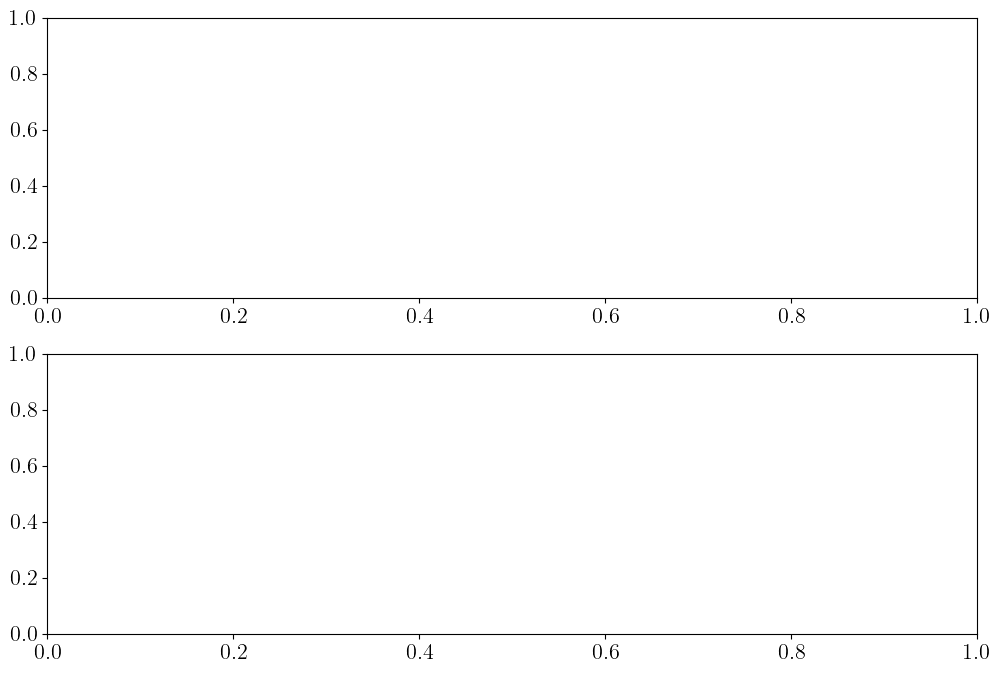

In [66]:
# Set parameters
time_dt_sub = time_dt[::6]
theta_m1 = theta_dict['mooring1']
theta_m2 = theta_dict['mooring2']
L_m1 = L_theta['mooring1']
L_m2 = L_theta['mooring2']
levels = np.arange(2,12,0.5)

# Create figure and axis
fig, axes = plt.subplots(2,1,figsize=(12,8))
ax1, ax2 = axes.flatten()

#-------------------------------
# Subplot 1 
#-------------------------------

# Plot decorrelation ellipses
pc = ax1.contourf(time_dt_sub[0:300],theta_m1,L_m1[0:300,:].T, levels=levels, cmap=cmo.deep_r, extend='both')

# Set figure attributes
ax1.set_ylabel(r'$\theta$ (deg)')
ax1.set_ylim(0,360)
ax1.set_yticks([0,90,180,270,360])
ax1.tick_params(top=True, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax1.set_xticklabels([])

#-------------------------------
# Subplot 2 
#-------------------------------

# Plot decorrelation ellipses
pc = ax2.contourf(time_dt_sub[0:300],theta_m2,L_m2[0:300,:].T, levels=levels, cmap=cmo.deep_r, extend='both')

# Set figure attributes
ax2.set_ylabel(r'$\theta$ (deg)')
ax2.set_ylim(0,360)
ax2.set_yticks([0,90,180,270,360])
ax2.tick_params(top=True, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Set color bar
cax = fig.add_axes([1, 0.3, 0.03, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (km)')

# Display figure
plt.tight_layout()
plt.show()

Compute the azimuthal integral of the decorrelation scale 

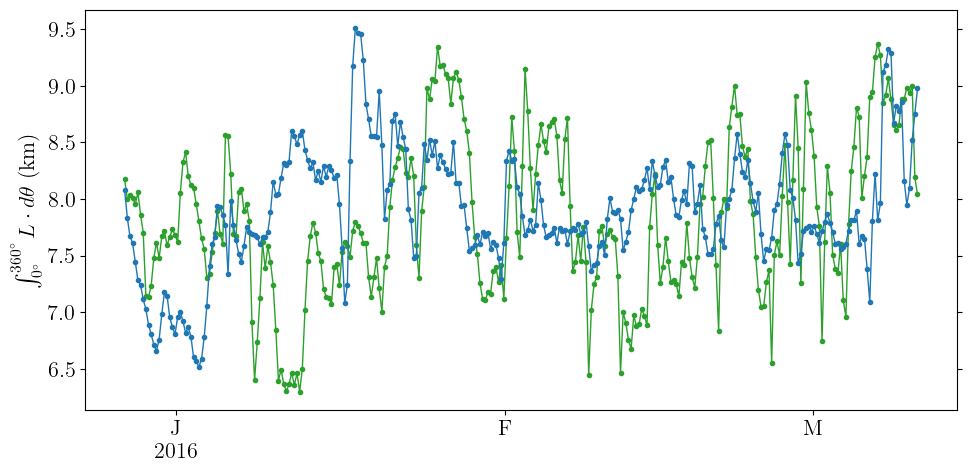

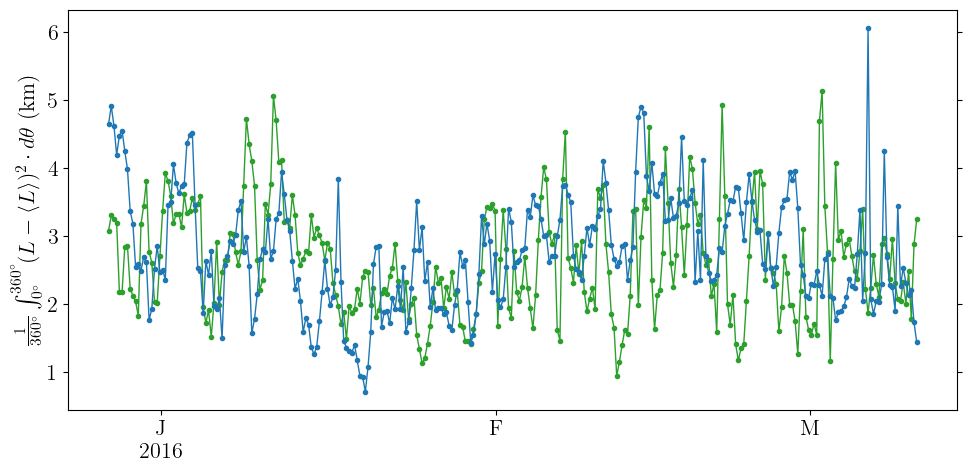

In [50]:
# Set the theta resolution and domain span 
dtheta1 = theta_m1[1] - theta_m1[0]
ntheta1 = theta_m1[-1] - theta_m1[0]
dtheta2 = theta_m2[1] - theta_m2[0]
ntheta2 = theta_m2[-1] - theta_m2[0]

# Compute azimuthal average 
L_mean1 = (1/ntheta1) * np.sum(L_m1 * dtheta1, axis=1)
L_mean2 = (1/ntheta2) * np.sum(L_m2 * dtheta2, axis=1)

# Compute azimuthal variance 
L_var1 = (1/ntheta1) * np.sum(((L_m1 - L_mean1[:, np.newaxis])**2) * dtheta1, axis=1)
L_var2 = (1/ntheta2) * np.sum(((L_m2 - L_mean2[:, np.newaxis])**2) * dtheta2, axis=1)

# Create figure
fig,ax = plt.subplots(figsize=(10,5))

# Plot azimuthally averaged decorrelation scale 
ax.plot(time_dt_sub[0:300], L_mean1[0:300], '.-', lw=1, color='tab:green')
ax.plot(time_dt_sub[0:300], L_mean2[0:300], '.-', lw=1, color='tab:blue')

# Set figure attributes
ax.set_ylabel(r'$\int_{0^\circ}^{360^\circ} L \cdot d\theta$ (km)')
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Display 
plt.tight_layout()
plt.show()

# Create figure
fig,ax = plt.subplots(figsize=(10,5))

# Plot azimuthally averaged decorrelation scale 
ax.plot(time_dt_sub[0:300], L_var1[0:300], '.-', lw=1, color='tab:green')
ax.plot(time_dt_sub[0:300], L_var2[0:300], '.-', lw=1, color='tab:blue')

# Set figure attributes
ax.set_ylabel(r'$\frac{1}{360^\circ} \int_{0^\circ}^{360^\circ} (L - \langle L \rangle)^2 \cdot d\theta$ (km)')
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Display 
plt.tight_layout()
plt.show()

## **Section 3**: Compute decorrelation scales ellipses for each month 
(obtain a climatological presepective of the decorrelation scales)

Now, let's compute the decorrelation scale ellipse at each mooring site

In [ ]:
# Set parameters
dt = 6

# Initialize arrays and counters
cn_m = 0
nmooring, ntime_full, ntime_sub = len(region_data.keys()), len(time_dt), len(range(0, len(time_dt), dt))
r_lag_dict     = {}
theta_dict     = {}
autocorr_dict  = {}

# Loop through moorings 
for name, region in region_data.items():

    # Set a key in the dictionary
    r_lag_dict[name]     = {}
    theta_dict[name]     = {}
    autocorr_dict[name]  = {}

    # Print the Name of the mooring 
    print('')
    print(name)

    # Extract data 
    data_c = region["data"]
    lon_c  = region["lon_subset"]
    lat_c  = region["lat_subset"]

    # Define the center of the grid and the mesh grid of latitude and longitude
    lon_center, lat_center = np.mean(lon_c), np.mean(lat_c)
    LON, LAT = np.meshgrid(lon_c, lat_c)

    # Map the first time step
    R0, THETA0, _, _ = interpolate_to_polar_grid(LON, LAT, np.squeeze(data_c[0,:,:]), lon_center, lat_center)

    # Convert r and theta output into vectors
    r = R0[0,:]
    theta = THETA0[:,0]*(180/np.pi)

    # Set number of angles and radial positions
    nr = len(r)
    ntheta = len(theta)
    dr = r[1] - r[0]

    # Initialize arrays and counter
    iautocorr = np.zeros((ntime_sub, nr, ntheta))
    cn_t = 0

    # Loop through time
    for itime in range(0,ntime_full,dt):

        # Set progress bar
        progress = itime / ntime_full
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Grab data from ith time step  
        idata = np.squeeze(data_c[itime,:,:])

        # Interpolate to polar grid (cropped to inscribed circle)
        R, THETA, data_polar, _ = interpolate_to_polar_grid(LON, LAT, idata, lon_center, lat_center)

         # Mask invalid (NaN or Inf) points 
        data_m = np.ma.masked_invalid(data_polar)

        # Loop through rotation angles 
        for iangle in range(0,ntheta): 

            # Detrend data record 
            data_dt = detrend(data_m[iangle,:], r, mean = 0)
            
            # Compute autocorrelation function at the ith angle 
            iautocorr[cn_t,:,iangle], _, _, _, r_lag, _ = compute_autocorr_optimize(data_dt, r, nr, 'biased', 0)

        # Reintialize counter
        cn_t += 1

    # Save data into dictionary 
    r_lag_dict[name]    = r_lag
    theta_dict[name]    = theta
    autocorr_dict[name] = np.array(iautocorr)

    # Reset mooring counter 
    cn_m += 1


mooring1
Progress: 100.0%
mooring2
Progress: 100.0%

Compute the monthly mean autocorrelation function

In [ ]:
# Set parameters
time_dt_sub = time_dt[::6]

# Convert time to monthly values 
time_months = np.array(time_dt_sub, dtype='datetime64[M]')

# Identify unique months (sorted) 
unique_months = np.unique(time_months)
nmonth = len(unique_months)

# Convert months to datetime for plotting
months_dt = unique_months.astype('datetime64[M]')

# Initialize arrays and counters
L_m_dict  = {} 
L_stdm_dict  = {} 
monthly_autocorr_dict = {}
monthly_autocorr_stdm_dict = {}

# Loop through moorings 
for name, autocorr_c in autocorr_dict.items():

    # Set a key in the dictionary
    L_m_dict[name]  = {}
    L_stdm_dict[name]  = {}
    monthly_autocorr_dict[name]  = {}

    # Obtain theta and r_lag variables from ith mooring and set number of angles
    itheta = theta_dict[name]
    r_lag  = r_lag_dict[name]
    ntheta = len(itheta)

    # Print the Name of the mooring 
    print(name)

    # Initialize monthly mean array 
    monthly_autocorr_m    = np.zeros((nmonth, autocorr_c.shape[1], autocorr_c.shape[2])) * np.nan
    monthly_autocorr_stdm = np.zeros((nmonth, autocorr_c.shape[1], autocorr_c.shape[2])) * np.nan
    monthly_L_m           = np.zeros((nmonth, autocorr_c.shape[2])) * np.nan
    monthly_L_stdm        = np.zeros((nmonth, autocorr_c.shape[2])) * np.nan

    # Loop through months 
    for i, month in enumerate(unique_months):

        # Grab indices for months
        idx = np.where(time_months == month)[0]

        # Handle cases where month is empty 
        if len(idx) > 0:

            # Compute monthly autocorrelation function 
            monthly_autocorr_m[i, :, :] = np.nanmean(autocorr_c[idx, :, :], axis=0)

            # Compute the standard deviation and the number of samples 
            autocorr_std = np.nanstd(autocorr_c, axis=0, ddof=1)
            autocorr_n   = np.count_nonzero(~np.isnan(autocorr_c), axis=0)

            # Compute the standard error of the mean (assuming that each data point is an independent observations)
            monthly_autocorr_stdm[i, :, :] = autocorr_std/np.sqrt(autocorr_n)

        # Loop through angles
        for iangle in range(0,ntheta): 

            # Compute the decorrelation scale from monthly mean autocorrelation
            monthly_L_m[i,iangle] = compute_decor_scale_optimize(monthly_autocorr_m[i, :, iangle], r_lag, dr, 'unbiased', 0)

            # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
            L_ustd = compute_decor_scale_optimize(monthly_autocorr_m[i, :, iangle] + monthly_autocorr_stdm[i, :, iangle] ,r_lag ,dr,'unbiased',0)
            L_lstd = compute_decor_scale_optimize(monthly_autocorr_m[i, :, iangle] - monthly_autocorr_stdm[i, :, iangle] ,r_lag ,dr,'unbiased',0)

            # Compute the average standard error 
            std_upper = L_ustd - monthly_L_m[i,iangle]
            std_lower = abs(L_lstd - monthly_L_m[i,iangle])
            monthly_L_stdm[i,iangle]  = np.mean([std_upper, std_lower])

    # Save data into dictionary 
    L_m_dict[name] = np.array(monthly_L_m)
    L_stdm_dict[name] = np.array(monthly_L_stdm)
    monthly_autocorr_dict[name] = np.array(monthly_autocorr_m)
    monthly_autocorr_stdm_dict[name] = np.array(monthly_autocorr_stdm)


mooring1

mooring2


Plot the monthly decorrelation scale ellipse

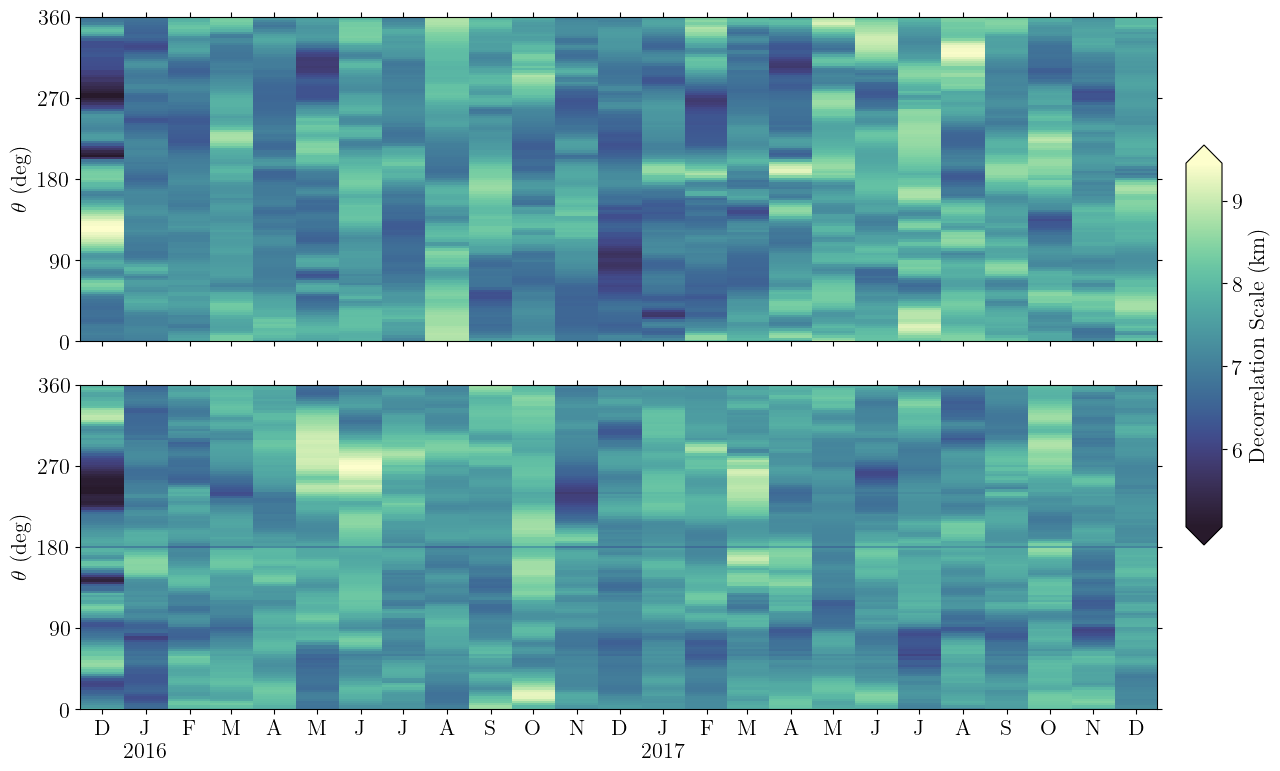

In [87]:
# Set parameters
theta_m1 = theta_dict['mooring1']
theta_m2 = theta_dict['mooring2']
L_m1 = L_m_dict['mooring1']
L_m2 = L_m_dict['mooring2']
levels = np.arange(2,12,0.5)

# Create figure and axis
fig, axes = plt.subplots(2,1,figsize=(12,8))
ax1, ax2 = axes.flatten()

#-------------------------------
# Subplot 1 
#-------------------------------

# Plot decorrelation ellipses
pc = ax1.pcolormesh(months_dt,theta_m1,L_m1.T, shading='auto', cmap=cmo.deep_r)

# Set figure attributes
ax1.set_ylabel(r'$\theta$ (deg)')
ax1.set_ylim(0,360)
ax1.set_yticks([0,90,180,270,360])
ax1.tick_params(top=True, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax1.set_xticklabels([])

#-------------------------------
# Subplot 2 
#-------------------------------

# Plot decorrelation ellipses
pc = ax2.pcolormesh(months_dt,theta_m2,L_m2.T, shading='auto', cmap=cmo.deep_r)

# Set figure attributes
ax2.set_ylabel(r'$\theta$ (deg)')
ax2.set_ylim(0,360)
ax2.set_yticks([0,90,180,270,360])
ax2.tick_params(top=True, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Set color bar
cax = fig.add_axes([1, 0.3, 0.03, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (km)')

# Display figure
plt.tight_layout()
plt.show()

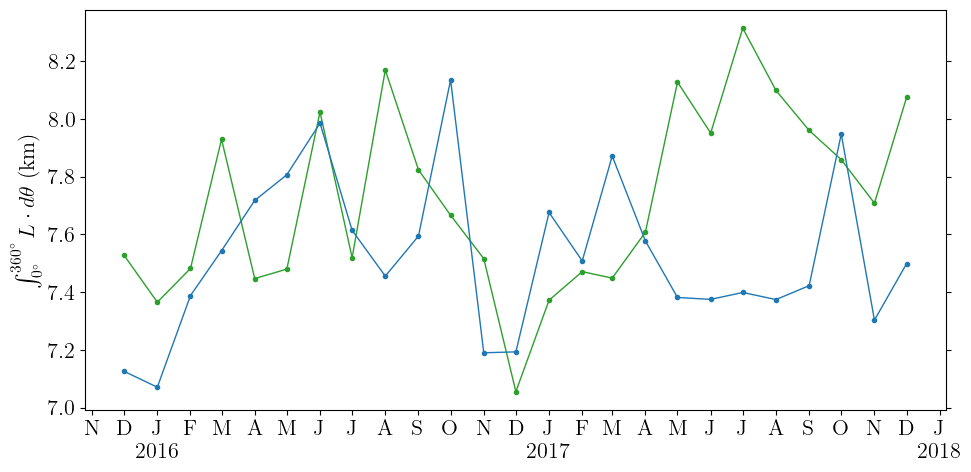

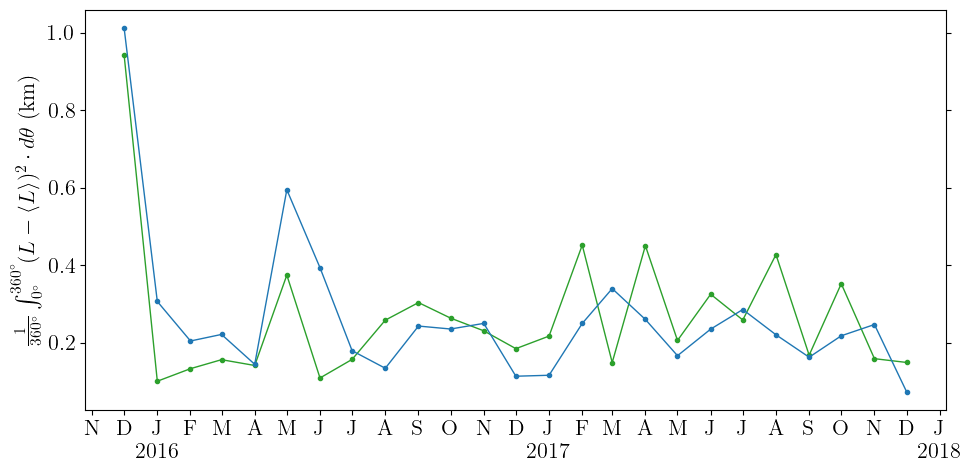

In [88]:
# Set the theta resolution and domain span 
dtheta1 = theta_m1[1] - theta_m1[0]
ntheta1 = theta_m1[-1] - theta_m1[0]
dtheta2 = theta_m2[1] - theta_m2[0]
ntheta2 = theta_m2[-1] - theta_m2[0]

# Compute azimuthal average 
L_mean1 = (1/ntheta1) * np.sum(L_m1 * dtheta1, axis=1)
L_mean2 = (1/ntheta2) * np.sum(L_m2 * dtheta2, axis=1)

# Compute azimuthal variance 
L_var1 = (1/ntheta1) * np.sum(((L_m1 - L_mean1[:, np.newaxis])**2) * dtheta1, axis=1)
L_var2 = (1/ntheta2) * np.sum(((L_m2 - L_mean2[:, np.newaxis])**2) * dtheta2, axis=1)

# Create figure
fig,ax = plt.subplots(figsize=(10,5))

# Plot azimuthally averaged decorrelation scale 
ax.plot(months_dt, L_mean1, '.-', lw=1, color='tab:green')
ax.plot(months_dt, L_mean2, '.-', lw=1, color='tab:blue')

# Set figure attributes
ax.set_ylabel(r'$\int_{0^\circ}^{360^\circ} L \cdot d\theta$ (km)')
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Display 
plt.tight_layout()
plt.show()

# Create figure
fig,ax = plt.subplots(figsize=(10,5))

# Plot azimuthally averaged decorrelation scale 
ax.plot(months_dt, L_var1, '.-', lw=1, color='tab:green')
ax.plot(months_dt, L_var2, '.-', lw=1, color='tab:blue')

# Set figure attributes
ax.set_ylabel(r'$\frac{1}{360^\circ} \int_{0^\circ}^{360^\circ} (L - \langle L \rangle)^2 \cdot d\theta$ (km)')
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Display 
plt.tight_layout()
plt.show()

## **Section 4**: Rotating the entire domain 

In [12]:
# Set parameters
dx, dy = 2, 2                             # Units: kilometers 
theta = np.arange(0,360+5,5)              # Units: degrees
seasons = ['winter', 'spring', 'summer']  

# Initialize arrays and counters
cn_m = 0
ntheta, nmooring, nseason = len(theta), len(region_data.keys()), len(seasons)
L_theta = np.zeros((nmooring, nseason, ntheta))
L_theta_stdm = np.zeros((nmooring, nseason, ntheta))

# Loop through moorings 
for name, region in region_data.items():

    # Print the Name of the mooring 
    print(name)

    # Extract data 
    idata = region["data"]
    ilon  = region["lon_subset"]
    ilat  = region["lat_subset"]

    # Initialize counter
    cn_s = 0

    # Loop through seasons
    for iseason in seasons:

        # Grab data snap shot from a season 
        if iseason == 'winter': 
            idata_s = np.squeeze(idata[idx_winter,:,:])
        elif iseason == 'spring':
            idata_s = np.squeeze(idata[idx_spring,:,:]) 
        elif iseason == 'summer': 
            idata_s = np.squeeze(idata[idx_summer,:,:])

        # Loop through rotation angles 
        for iangle in range(0,ntheta): 

            # Rotate data array into ith angle coordinate system 
            data_n, X_n, Y_n = rotate_field(idata_s, ilon, ilat, theta[iangle], dx_r = dx, dy_r = dy)
            x_cor = Y_n[0,:]
            y_cor = Y_n[:,0]

            # convert to masked array with no elements masked
            data_m = np.ma.array(data_n, mask=np.zeros_like(data_n, dtype=bool))

            # Initialize array
            nx = len(x_cor)
            ny = len(y_cor)
            autocorr = np.zeros((ny,nx))

            # Loop through x-coordinates 
            for ix in range(0,nx-1): 

                # Detrend data record 
                data_dt = detrend(data_m[:,ix], y_cor, mean = 0)

                # Compute autocorrelation function across the y-coordinate 
                autocorr[:,ix], _, _, _, space_lag, _ = compute_autocorr_optimize(data_dt, y_cor, ny, 'biased', 0)

            # Compute the mean autocorrelation 
            autocorr_m = np.nanmean(autocorr,axis=1)

            # Compute the standard deviation and the number of samples 
            autocorr_std = np.nanstd(autocorr, axis=1, ddof=1)
            autocorr_n   = np.count_nonzero(~np.isnan(autocorr), axis=1)

            # Compute the standard error of the mean (assuming that each data point is an independent observations)
            autocorr_stdm = autocorr_std/np.sqrt(autocorr_n)

            # Compute the decorrelation scale 
            L_theta[cn_m,cn_s,iangle] = compute_decor_scale_optimize(autocorr_m, space_lag, dy, 'unbiased', 0)

            # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
            L_ustd = compute_decor_scale_optimize(autocorr_m + autocorr_stdm ,space_lag ,dy,'unbiased',0)
            L_lstd = compute_decor_scale_optimize(autocorr_m - autocorr_stdm ,space_lag ,dy,'unbiased',0)

            # Compute the average standard error 
            std_upper = L_ustd - L_theta[cn_m,cn_s,iangle]
            std_lower = abs(L_lstd - L_theta[cn_m,cn_s,iangle])
            L_theta_stdm[cn_m,cn_s,iangle]  = np.mean([std_upper, std_lower])

        # Reset season counter 
        cn_s += 1

    # Reset mooring counter 
    cn_m += 1

mooring1
mooring2


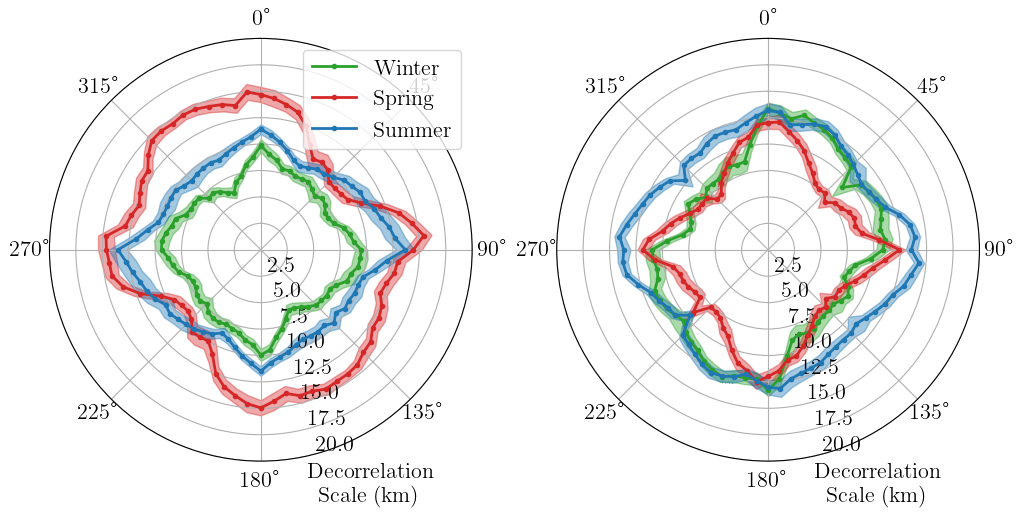

In [18]:
# Set plotting parameter 
theta_rad = np.deg2rad(theta)
r_grid = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
r_labeled = [5, 10, 15, 20]

# Create figure and axes 
fig, axes = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection': 'polar'})
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 

# Plot the decorrelation ellipse
ax1.plot(theta_rad,L_theta[0,0,:],'.-', color='tab:green', linewidth=2, label='Winter')
ax1.plot(theta_rad,L_theta[0,1,:],'.-', color='tab:red', linewidth=2, label='Spring')
ax1.plot(theta_rad,L_theta[0,2,:],'.-', color='tab:blue', linewidth=2, label='Summer')

# Plot standard error of the mean 
ax1.fill_between(theta_rad, L_theta[0,0,:] + L_theta_stdm[0,0,:], L_theta[0,0,:] - L_theta_stdm[0,0,:], color='tab:green', alpha=0.4)
ax1.fill_between(theta_rad, L_theta[0,1,:] + L_theta_stdm[0,1,:], L_theta[0,1,:] - L_theta_stdm[0,1,:], color='tab:red', alpha=0.4)
ax1.fill_between(theta_rad, L_theta[0,2,:] + L_theta_stdm[0,2,:], L_theta[0,2,:] - L_theta_stdm[0,2,:], color='tab:blue', alpha=0.4)

# Set figure attributes 
ax1.set_theta_zero_location('N')   
ax1.set_theta_direction(-1)        
ax1.set_rmax(20.0)
ax1.set_rgrids(r_grid, angle=165)
ax1.text(np.deg2rad(155), 24.5, f"Decorrelation\nScale (km)", ha='center', va='center')
ax1.grid(True)
ax1.legend()

#--- Subplot 2 ---# 

# Plot the decorrelation ellipse
ax2.plot(theta_rad,L_theta[1,0,:],'.-', color='tab:green', linewidth=2)
ax2.plot(theta_rad,L_theta[1,1,:],'.-', color='tab:red', linewidth=2)
ax2.plot(theta_rad,L_theta[1,2,:],'.-', color='tab:blue', linewidth=2)

# Plot standard error of the mean 
ax2.fill_between(theta_rad, L_theta[1,0,:] + L_theta_stdm[1,0,:], L_theta[1,0,:] - L_theta_stdm[1,0,:], color='tab:green', alpha=0.4)
ax2.fill_between(theta_rad, L_theta[1,1,:] + L_theta_stdm[1,1,:], L_theta[1,1,:] - L_theta_stdm[1,1,:], color='tab:red', alpha=0.4)
ax2.fill_between(theta_rad, L_theta[1,2,:] + L_theta_stdm[1,2,:], L_theta[1,2,:] - L_theta_stdm[1,2,:], color='tab:blue', alpha=0.4)

# Set figure attributes 
ax2.set_theta_zero_location('N')   
ax2.set_theta_direction(-1)        
ax2.set_rmax(20.0)
ax2.set_rgrids(r_grid, angle=165)
ax2.text(np.deg2rad(155), 24.5, f"Decorrelation\nScale (km)", ha='center', va='center')
ax2.grid(True)

In [ ]:
# Plot in Cartesian coordinates
fig, ax = plt.subplots(figsize=(6, 6))
p = ax.pcolormesh(LON, LAT, idata_s, cmap='viridis', shading='auto')
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.set_title('Cartesian Grid')
ax.set_xlabel('Lon (degrees)')
ax.set_ylabel('Lat (degrees)')
ax.grid(False)
plt.show()

# 5. Plot results in polar coordinates
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
p = ax.pcolormesh(THETA, R, data_polar, cmap='viridis', shading='auto')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(p, ax=ax, label='Density (kg/m³)')
ax.grid(False)
plt.show()

In [ ]:
# Set parameters
dx, dy = 2, 2                             # Units: kilometers 
theta = np.arange(0,360+5,5)              # Units: degrees
dt = 6

# Initialize arrays and counters
cn_m = 0
ntheta, nmooring, ntime = len(theta), len(region_data.keys()), len(time_dt)/6
L_theta = np.zeros((nmooring, ntime, ntheta))
L_theta_stdm = np.zeros((nmooring, ntime, ntheta))

# Loop through moorings 
for name, region in region_data.items():

    # Print the Name of the mooring 
    print('')
    print(name)

    # Extract data 
    data_c = region["data"]
    lon_c  = region["lon_subset"]
    lat_c  = region["lat_subset"]

    # Initialize counter
    cn_s = 0

    # Loop through time
    for itime in range(0,ntime,dt):

        # Set progress bar
        progress = itime / ntime
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Grab data from ith time step  
        idata = np.squeeze(data_c[itime,:,:])

        # Loop through rotation angles 
        for iangle in range(0,ntheta): 

            # Rotate data array into ith angle coordinate system 
            data_n, X_n, Y_n = rotate_field(idata, lon_c, lat_c, theta[iangle], dx_r = dx, dy_r = dy)
            x_cor = Y_n[0,:]
            y_cor = Y_n[:,0]

            # convert to masked array with no elements masked
            data_m = np.ma.array(data_n, mask=np.zeros_like(data_n, dtype=bool))

            # Initialize array
            nx = len(x_cor)
            ny = len(y_cor)
            autocorr = np.zeros((ny,nx))

            # Loop through x-coordinates 
            for ix in range(0,nx-1): 

                # Detrend data record 
                data_dt = detrend(data_m[:,ix], y_cor, mean = 0)

                # Compute autocorrelation function across the y-coordinate 
                autocorr[:,ix], _, _, _, space_lag, _ = compute_autocorr_optimize(data_dt, y_cor, ny, 'biased', 0)

            # Compute the mean autocorrelation 
            autocorr_m = np.nanmean(autocorr,axis=1)

            # Compute the standard deviation and the number of samples 
            autocorr_std = np.nanstd(autocorr, axis=1, ddof=1)
            autocorr_n   = np.count_nonzero(~np.isnan(autocorr), axis=1)

            # Compute the standard error of the mean (assuming that each data point is an independent observations)
            autocorr_stdm = autocorr_std/np.sqrt(autocorr_n)

            # Compute the decorrelation scale 
            L_theta[cn_m,cn_s,iangle] = compute_decor_scale_optimize(autocorr_m, space_lag, dy, 'unbiased', 0)

            # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
            L_ustd = compute_decor_scale_optimize(autocorr_m + autocorr_stdm ,space_lag ,dy,'unbiased',0)
            L_lstd = compute_decor_scale_optimize(autocorr_m - autocorr_stdm ,space_lag ,dy,'unbiased',0)

            # Compute the average standard error 
            std_upper = L_ustd - L_theta[cn_m,cn_s,iangle]
            std_lower = abs(L_lstd - L_theta[cn_m,cn_s,iangle])
            L_theta_stdm[cn_m,cn_s,iangle]  = np.mean([std_upper, std_lower])

        # Reset season counter 
        cn_s += 1

    # Reset mooring counter 
    cn_m += 1

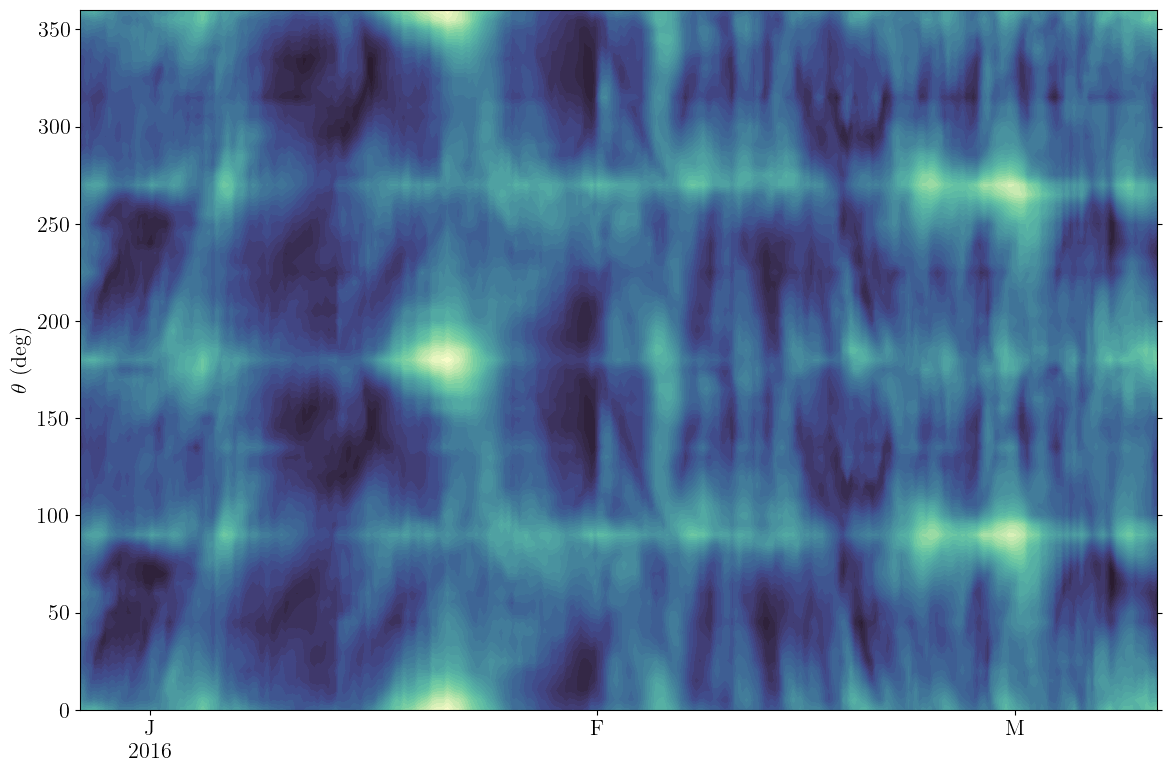

In [ ]:
# Set parameters
L_m1 = np.squeeze(L_theta[0,:,:]) 
L_m2 = np.squeeze(L_theta[1,:,:]) 
time_dt_sub = time_dt[::6]

# Remove columns where all entries are zero
L_m1_clean = L_m1[ ~(np.all(L_m1 == 0, axis=1)),:]
L_m2_clean = L_m2[ ~(np.all(L_m2 == 0, axis=1)),:]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,8))

# Plot decorrelation ellipses
ax.contourf(time_dt_sub[0:300],theta,L_m1_clean[0:300,:].T, levels=40, cmap=cmo.deep_r)

# Set figure attributes
ax.set_ylabel(r'$\theta$ (deg)')
ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Display figure
plt.tight_layout()
plt.show()

In [ ]:
# # Overlay extracted regions
# for name, region in region_data.items():
#     lat_box = region['lat_subset']
#     lon_box = region['lon_subset']
#     lat_center = np.mean(lat_box)
#     lon_center = np.mean(lon_box)
    
#     # Plot box outline
#     ax.plot(
#         [lon_box.min(), lon_box.max(), lon_box.max(), lon_box.min(), lon_box.min()],
#         [lat_box.min(), lat_box.min(), lat_box.max(), lat_box.max(), lat_box.min()],
#         color='black', linewidth=2, label=name, transform=ccrs.PlateCarree()
#     )
    
#     # Plot center point
#     ax.plot(lon_center, lat_center, 'o', markersize=10, label=f"{name} center", transform=ccrs.PlateCarree())
